# 🍷 Red Wine Quality Prediction — Complete ML Project
### Steps: Load → EDA (dtale) → Preprocessing → Model Training (Before & After Tuning) → Comparison → Best Model


In [3]:
# ── Install required libraries (run once) ──────────────────────────
import subprocess, sys
pkgs = ["dtale", "xgboost", "scikit-learn", "seaborn", "matplotlib",
        "pandas", "numpy", "joblib"]
for p in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", p, "-q"],
                   capture_output=True)
print("✅ All packages ready")


✅ All packages ready


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import joblib

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.style.use("seaborn-v0_8-whitegrid")
print("✅ Imports done")


✅ Imports done


## Load Dataset

In [5]:
df = pd.read_csv("winequality-red.csv")

# Fix column names: strip spaces → keep consistent with original file
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(3)


Shape: (1599, 12)

Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5


## Visual Exploration with dtale


In [6]:
import dtale
d = dtale.show(df, open_browser=False)
print("✅ dtale running at:", d._url)
d   # renders inline in Jupyter


✅ dtale running at: http://DELL:40000


## Data Preprocessing

In [7]:
# ── 3.1 Basic info ───────────────────────────────────────────────────────────
print("=" * 50)
print("SHAPE:", df.shape)
print("\nDTYPES:\n", df.dtypes)
print("\nMISSING VALUES:\n", df.isnull().sum())
print("\nDUPLICATES:", df.duplicated().sum())


SHAPE: (1599, 12)

DTYPES:
 fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

MISSING VALUES:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

DUPLICATES: 240


Removed 240 duplicates  →  1359 rows remain


2026-04-01 15:32:05,587 - INFO     - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-01 15:32:05,614 - INFO     - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


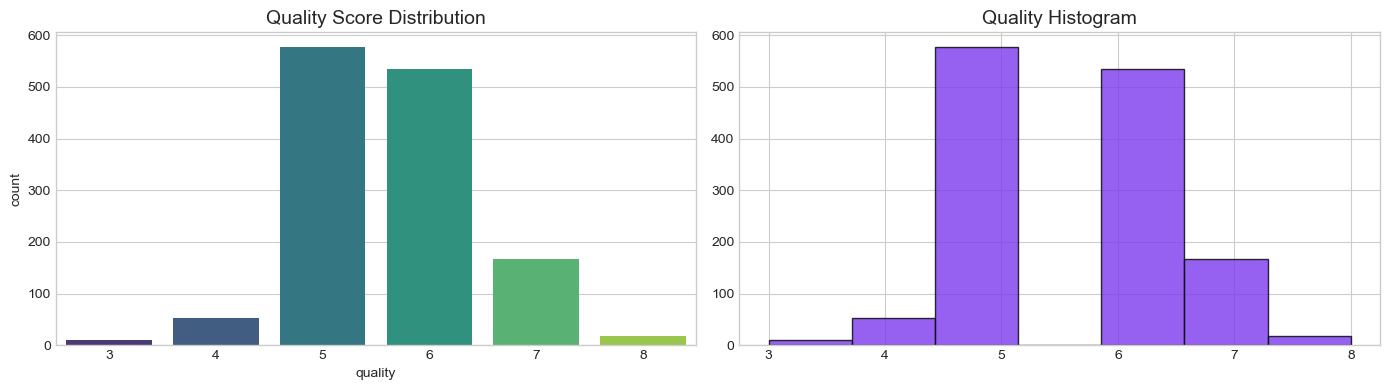


Quality value counts:
 quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


In [8]:
# ── 3.2 Remove duplicates ────────────────────────────────────────────────────
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicates  →  {len(df)} rows remain")

# ── 3.3 Target distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(x="quality", data=df, palette="viridis", ax=axes[0])
axes[0].set_title("Quality Score Distribution")
axes[1].hist(df["quality"], bins=7, edgecolor="black", color="#7c3aed", alpha=0.8)
axes[1].set_title("Quality Histogram")
plt.tight_layout()
plt.show()
print("\nQuality value counts:\n", df["quality"].value_counts().sort_index())


In [9]:
# ── 3.4 Outlier removal using IQR ───────────────────────────────────────────
features = [c for c in df.columns if c != "quality"]
before = len(df)
for col in features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]
print(f"After outlier removal: {len(df)} rows  (removed {before - len(df)})")
df.shape


After outlier removal: 1217 rows  (removed 142)


(1217, 12)

In [10]:
# ── 3.5 Feature Engineering ─────────────────────────────────────────────────
df["acidity_ratio"]   = df["fixed acidity"] / (df["volatile acidity"] + 1e-9)
df["so2_ratio"]       = df["free sulfur dioxide"] / (df["total sulfur dioxide"] + 1e-9)
df["alcohol_density"] = df["alcohol"] / df["density"]

print("New features added: acidity_ratio, so2_ratio, alcohol_density")
df[["acidity_ratio", "so2_ratio", "alcohol_density"]].describe().round(3)


New features added: acidity_ratio, so2_ratio, alcohol_density


,acidity_ratio,so2_ratio,alcohol_density
count,1217.000,1217.000,1217.000
mean,18.218,0.388,10.483
std,9.093,0.155,1.083
min,4.808,0.036,8.393
25%,11.579,0.263,9.539
50%,15.102,0.381,10.216
75%,22.927,0.500,11.166
max,74.167,0.857,14.130


In [11]:
# ── 3.6 Train / Test Split & Scaling ────────────────────────────────────────
X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  Test: {X_test.shape}")
print("Scaling done ✅")


Train: (973, 14)  Test: (244, 14)
Scaling done ✅


## Exploratory Data Analysis (EDA)

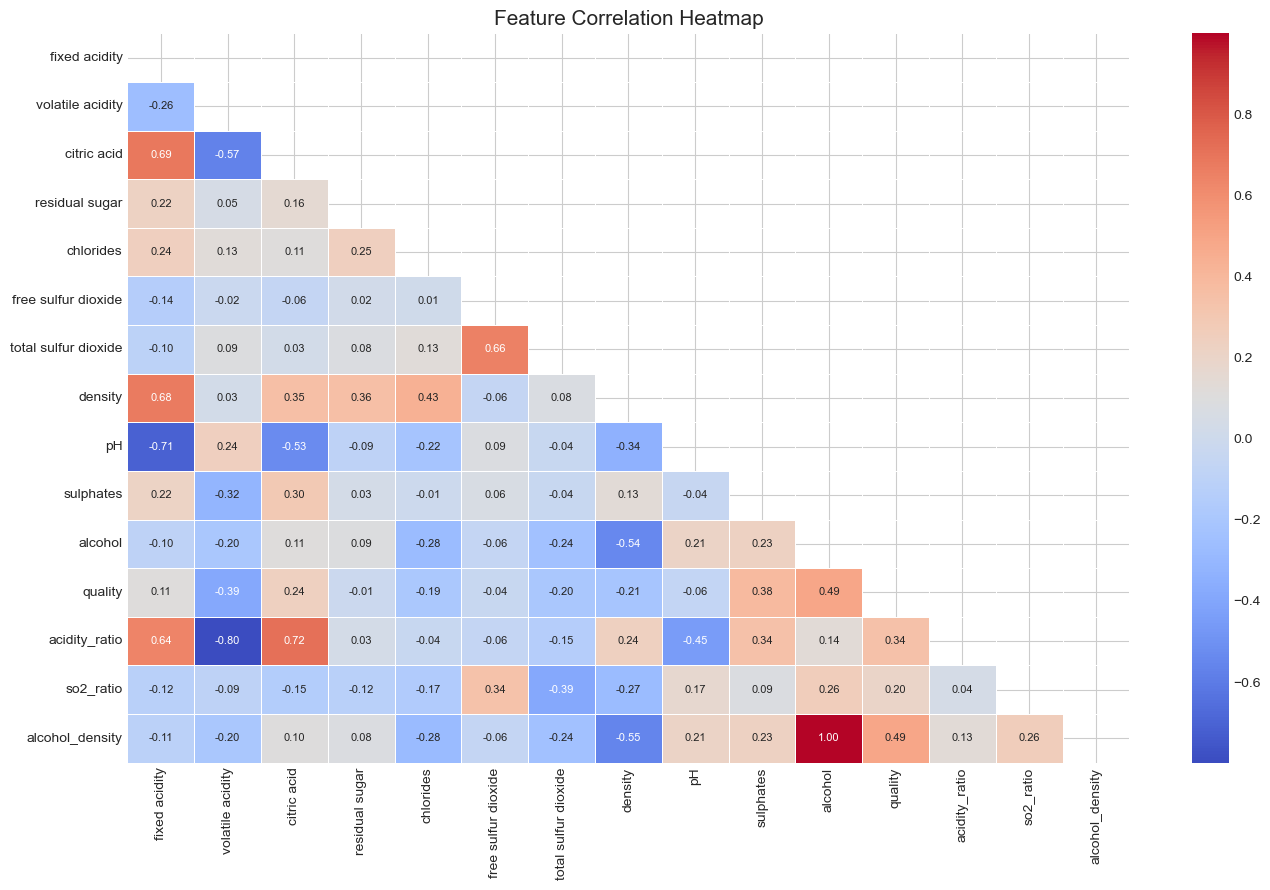

In [12]:
# ── 4.1 Correlation Heatmap ──────────────────────────────────────────────────
plt.figure(figsize=(14, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap", fontsize=15)
plt.tight_layout()
plt.show()


2026-04-01 15:32:08,295 - INFO     - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-01 15:32:08,324 - INFO     - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-01 15:32:08,486 - INFO     - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-01 15:32:08,496 - INFO     - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-01 15:32:08,620 - INFO     - Using categorical units to plot a list of strings that 

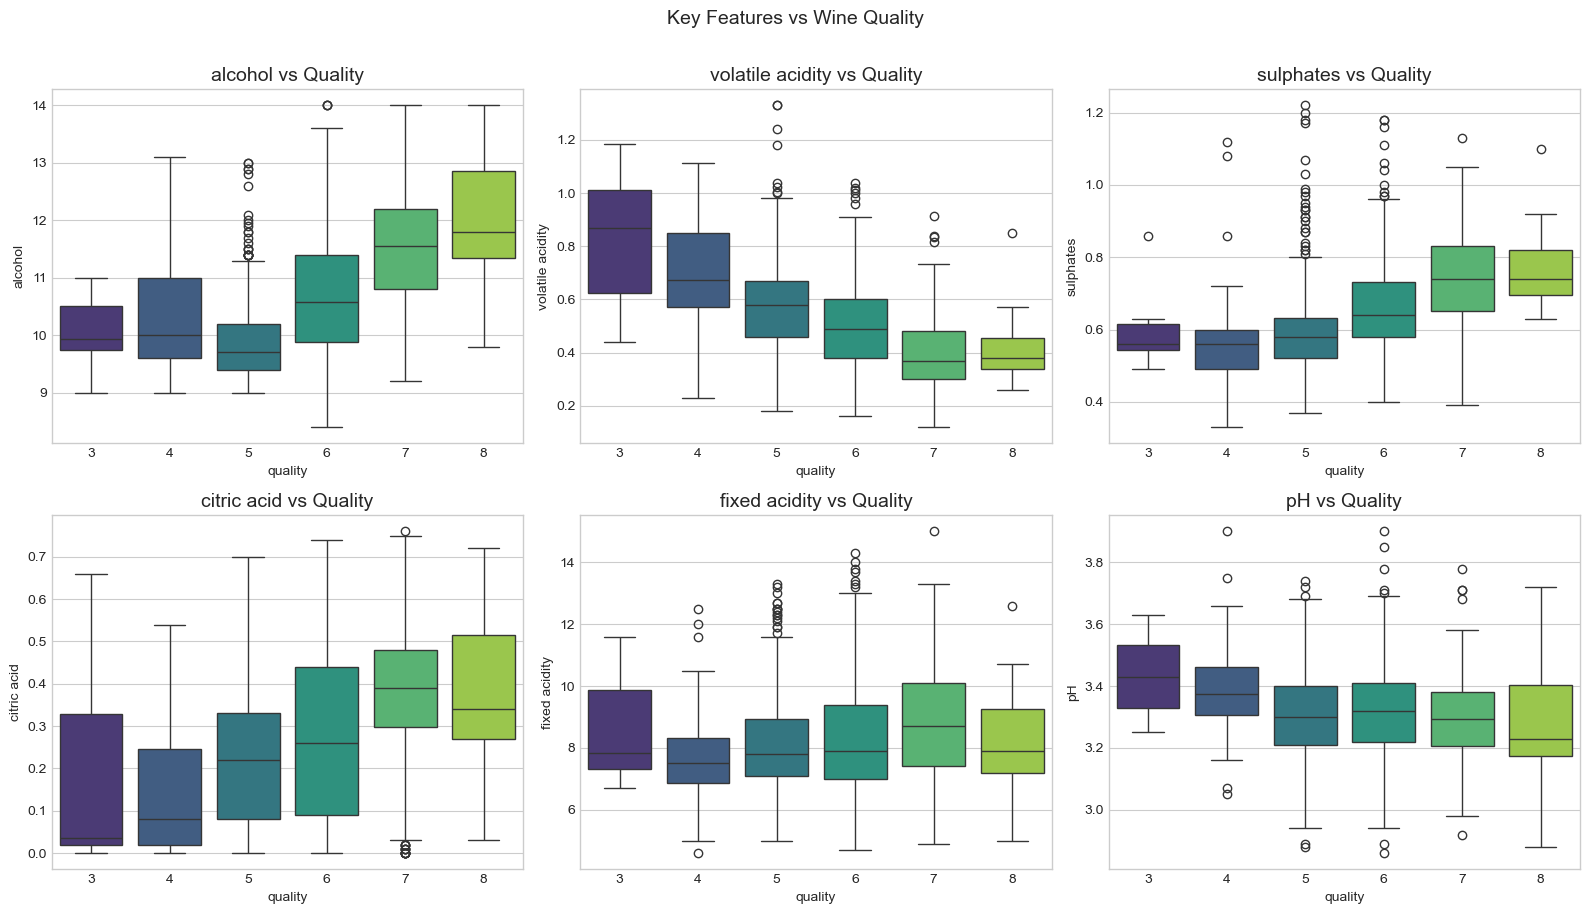

In [13]:
# ── 4.2 Feature distributions vs Quality (box plots) ───────────────────────
important_features = ["alcohol", "volatile acidity", "sulphates",
                      "citric acid", "fixed acidity", "pH"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, feat in enumerate(important_features):
    sns.boxplot(x="quality", y=feat, data=df,
                palette="viridis", ax=axes[i])
    axes[i].set_title(f"{feat} vs Quality")
plt.suptitle("Key Features vs Wine Quality", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


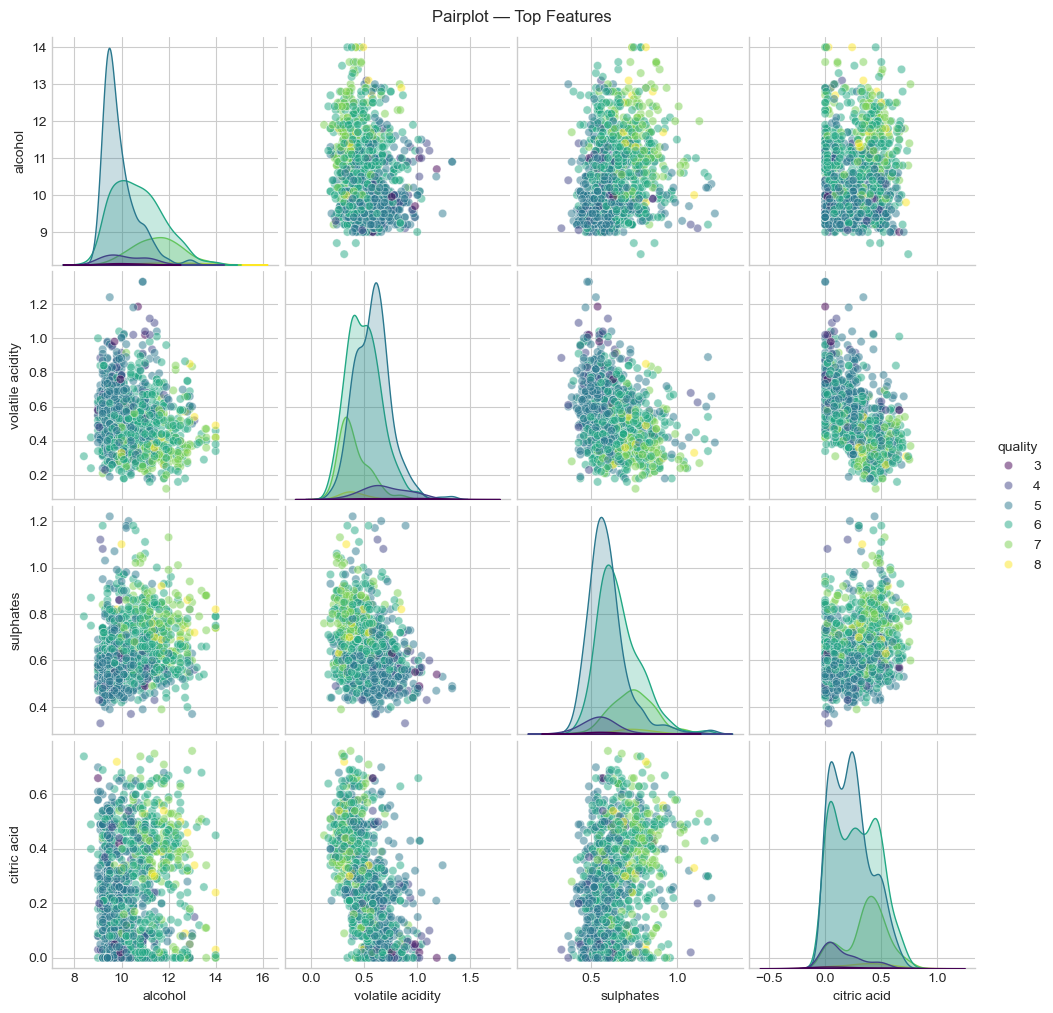

In [14]:
# ── 4.3 Pairplot of top correlated features ─────────────────────────────────
top_feats = ["alcohol", "volatile acidity", "sulphates", "citric acid", "quality"]
sns.pairplot(df[top_feats], hue="quality",
             palette="viridis", diag_kind="kde", plot_kws={"alpha": 0.5})
plt.suptitle("Pairplot — Top Features", y=1.01)
plt.show()


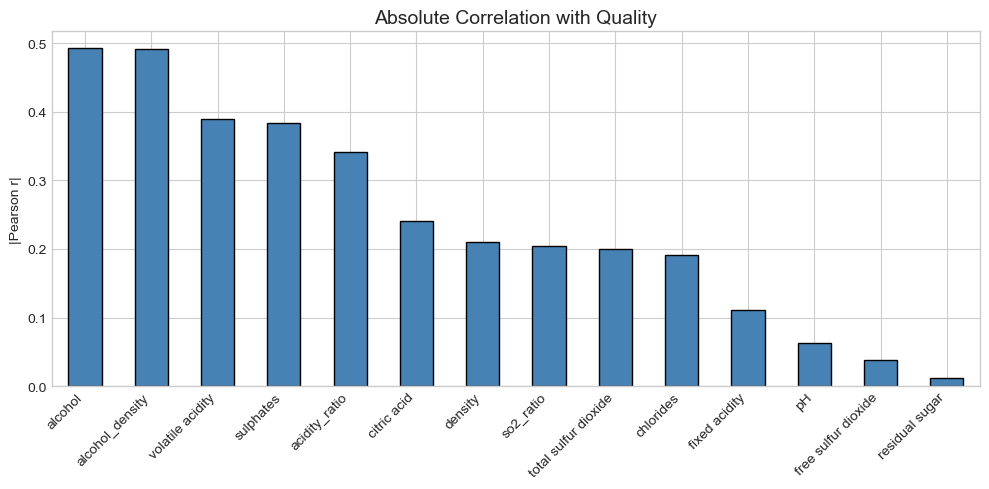

alcohol                 0.492638
alcohol_density         0.491536
volatile acidity        0.389495
sulphates               0.384219
acidity_ratio           0.340790
citric acid             0.240984
density                 0.209674
so2_ratio               0.204345
total sulfur dioxide    0.199557
chlorides               0.190821
fixed acidity           0.110913
pH                      0.062303
free sulfur dioxide     0.038777
residual sugar          0.011870
Name: quality, dtype: float64


In [15]:
# ── 4.4 Feature importance preview (univariate correlation) ─────────────────
correlations = df.corr()["quality"].drop("quality").abs().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
correlations.plot(kind="bar", color="steelblue", ax=ax, edgecolor="black")
ax.set_title("Absolute Correlation with Quality")
ax.set_ylabel("|Pearson r|")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print(correlations)


## Model Training: Before & After Fine-Tuning

In [16]:
# ── Helper: compute all metrics ─────────────────────────────────────────────
def get_metrics(name, y_true, y_pred, cv_scores=None):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    cv   = cv_scores.mean() if cv_scores is not None else None
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")
    if cv: print(f"  CV R²: {cv:.4f}  (±{cv_scores.std():.4f})")
    return {"Model": name, "MAE": round(mae,4), "RMSE": round(rmse,4),
            "R2": round(r2,4), "CV_R2": round(float(cv),4) if cv else None}

results = []   # will collect all rows


### Random Forest

In [17]:
# ── BEFORE Fine-Tuning ───────────────────────────────────────────────────────
rf_base = RandomForestRegressor(n_estimators=100, random_state=42)
rf_base.fit(X_train_sc, y_train)
rf_base_pred = rf_base.predict(X_test_sc)
cv_rf_base   = cross_val_score(rf_base, X_train_sc, y_train,
                               cv=5, scoring="r2")
m = get_metrics("Random Forest — Before Tuning", y_test, rf_base_pred, cv_rf_base)
results.append(m)



  Random Forest — Before Tuning
  MAE  : 0.4910
  RMSE : 0.6324
  R²   : 0.4214
  CV R²: 0.3734  (±0.0644)


In [18]:
# ── AFTER Fine-Tuning (GridSearchCV) ─────────────────────────────────────────
rf_param_grid = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [None, 10, 20],
    "min_samples_split": [2, 5],
    "max_features":      ["sqrt", "log2"]
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42),
                       rf_param_grid, cv=5,
                       scoring="r2", n_jobs=-1, verbose=0)
rf_grid.fit(X_train_sc, y_train)
print("Best RF params:", rf_grid.best_params_)

rf_tuned      = rf_grid.best_estimator_
rf_tuned_pred = rf_tuned.predict(X_test_sc)
cv_rf_tuned   = cross_val_score(rf_tuned, X_train_sc, y_train,
                                cv=5, scoring="r2")
m = get_metrics("Random Forest — After Tuning", y_test, rf_tuned_pred, cv_rf_tuned)
results.append(m)


Best RF params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}

  Random Forest — After Tuning
  MAE  : 0.4985
  RMSE : 0.6288
  R²   : 0.4279
  CV R²: 0.3920  (±0.0625)


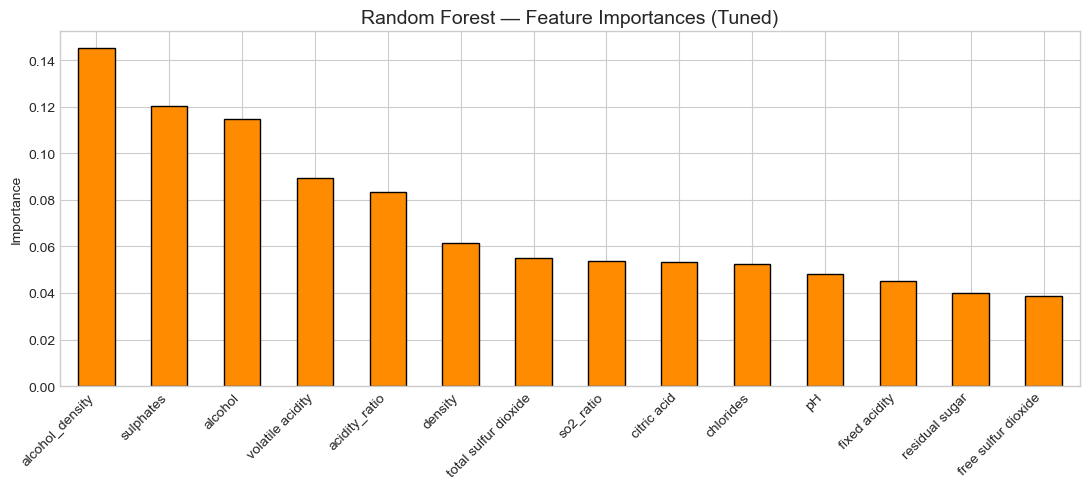

In [19]:
# ── RF Feature Importance ────────────────────────────────────────────────────
feat_imp = pd.Series(rf_tuned.feature_importances_,
                     index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 5))
feat_imp.plot(kind="bar", color="darkorange", edgecolor="black", ax=ax)
ax.set_title("Random Forest — Feature Importances (Tuned)")
ax.set_ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


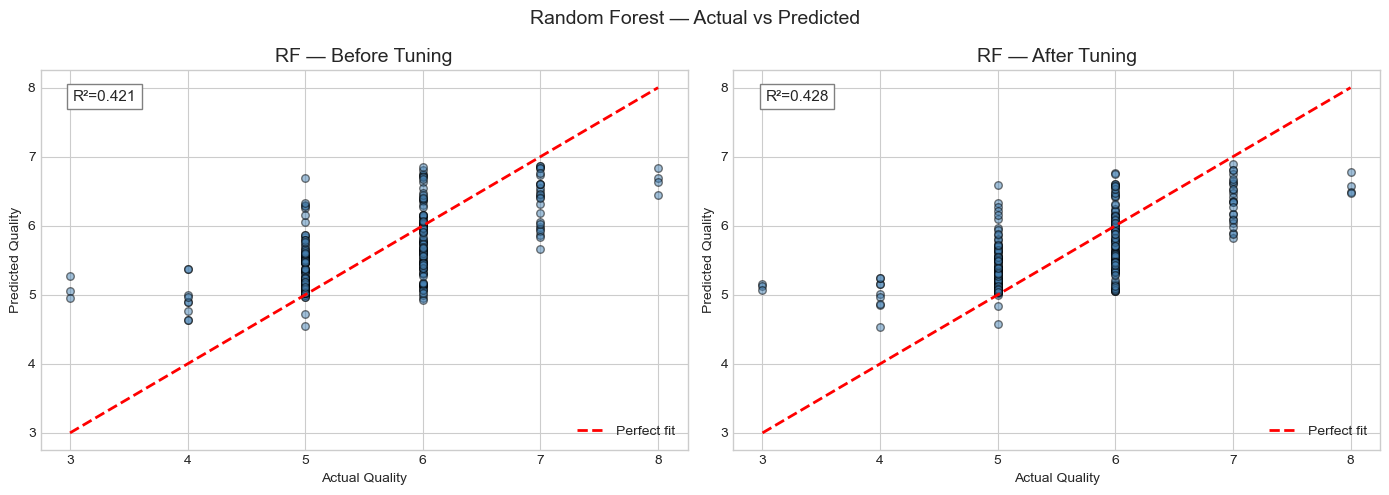

In [20]:
# ── RF Before vs After — Actual vs Predicted scatter ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pred, title in zip(
        axes,
        [rf_base_pred, rf_tuned_pred],
        ["RF — Before Tuning", "RF — After Tuning"]):
    ax.scatter(y_test, pred, alpha=0.5, color="steelblue", edgecolors="k", s=30)
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], "r--", lw=2, label="Perfect fit")
    ax.set_xlabel("Actual Quality")
    ax.set_ylabel("Predicted Quality")
    ax.set_title(title)
    ax.legend()
    ax.text(0.05, 0.92,
            f"R²={r2_score(y_test, pred):.3f}",
            transform=ax.transAxes, fontsize=11,
            bbox=dict(facecolor="white", edgecolor="gray"))
plt.suptitle("Random Forest — Actual vs Predicted", fontsize=14)
plt.tight_layout()
plt.show()


### Gradient Boosting

In [21]:
# ── BEFORE Fine-Tuning ───────────────────────────────────────────────────────
gb_base = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_base.fit(X_train_sc, y_train)
gb_base_pred = gb_base.predict(X_test_sc)
cv_gb_base   = cross_val_score(gb_base, X_train_sc, y_train,
                               cv=5, scoring="r2")
m = get_metrics("Gradient Boosting — Before Tuning", y_test, gb_base_pred, cv_gb_base)
results.append(m)



  Gradient Boosting — Before Tuning
  MAE  : 0.5048
  RMSE : 0.6417
  R²   : 0.4043
  CV R²: 0.3611  (±0.0648)


In [22]:
# ── AFTER Fine-Tuning ────────────────────────────────────────────────────────
gb_param_grid = {
    "n_estimators":   [100, 200, 300],
    "learning_rate":  [0.05, 0.1, 0.2],
    "max_depth":      [3, 5, 7],
    "subsample":      [0.8, 1.0]
}
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42),
                       gb_param_grid, cv=5,
                       scoring="r2", n_jobs=-1, verbose=0)
gb_grid.fit(X_train_sc, y_train)
print("Best GB params:", gb_grid.best_params_)

gb_tuned      = gb_grid.best_estimator_
gb_tuned_pred = gb_tuned.predict(X_test_sc)
cv_gb_tuned   = cross_val_score(gb_tuned, X_train_sc, y_train,
                                cv=5, scoring="r2")
m = get_metrics("Gradient Boosting — After Tuning", y_test, gb_tuned_pred, cv_gb_tuned)
results.append(m)


Best GB params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

  Gradient Boosting — After Tuning
  MAE  : 0.4979
  RMSE : 0.6363
  R²   : 0.4142
  CV R²: 0.3864  (±0.0691)


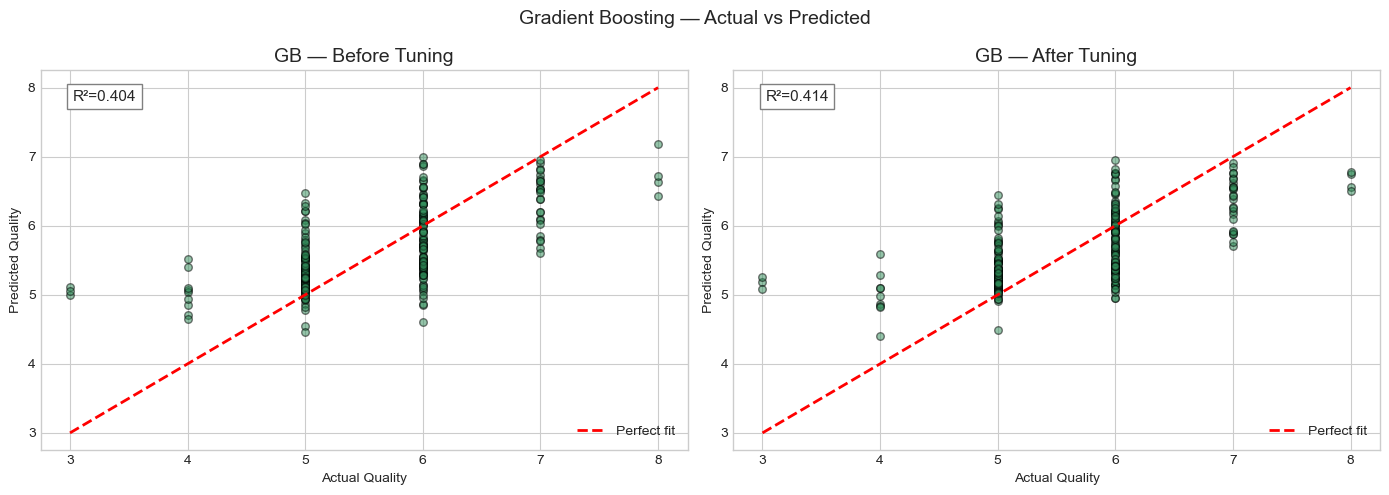

In [23]:
# ── GB Before vs After — Actual vs Predicted scatter ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pred, title in zip(
        axes,
        [gb_base_pred, gb_tuned_pred],
        ["GB — Before Tuning", "GB — After Tuning"]):
    ax.scatter(y_test, pred, alpha=0.5, color="seagreen", edgecolors="k", s=30)
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], "r--", lw=2, label="Perfect fit")
    ax.set_xlabel("Actual Quality")
    ax.set_ylabel("Predicted Quality")
    ax.set_title(title)
    ax.legend()
    ax.text(0.05, 0.92, f"R²={r2_score(y_test, pred):.3f}",
            transform=ax.transAxes, fontsize=11,
            bbox=dict(facecolor="white", edgecolor="gray"))
plt.suptitle("Gradient Boosting — Actual vs Predicted", fontsize=14)
plt.tight_layout()
plt.show()


### XGBoost

In [24]:
# ── BEFORE Fine-Tuning ───────────────────────────────────────────────────────
xgb_base = xgb.XGBRegressor(n_estimators=100, random_state=42,
                             eval_metric="rmse", verbosity=0)
xgb_base.fit(X_train_sc, y_train)
xgb_base_pred = xgb_base.predict(X_test_sc)
cv_xgb_base   = cross_val_score(xgb_base, X_train_sc, y_train,
                                cv=5, scoring="r2")
m = get_metrics("XGBoost — Before Tuning", y_test, xgb_base_pred, cv_xgb_base)
results.append(m)



  XGBoost — Before Tuning
  MAE  : 0.5057
  RMSE : 0.6606
  R²   : 0.3686
  CV R²: 0.2666  (±0.0990)


In [25]:
# ── AFTER Fine-Tuning ────────────────────────────────────────────────────────
xgb_param_grid = {
    "n_estimators":  [100, 200, 300],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth":     [3, 5, 7],
    "subsample":     [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}
xgb_grid = GridSearchCV(
    xgb.XGBRegressor(random_state=42, eval_metric="rmse", verbosity=0),
    xgb_param_grid, cv=5, scoring="r2", n_jobs=-1, verbose=0)
xgb_grid.fit(X_train_sc, y_train)
print("Best XGB params:", xgb_grid.best_params_)

xgb_tuned      = xgb_grid.best_estimator_
xgb_tuned_pred = xgb_tuned.predict(X_test_sc)
cv_xgb_tuned   = cross_val_score(xgb_tuned, X_train_sc, y_train,
                                 cv=5, scoring="r2")
m = get_metrics("XGBoost — After Tuning", y_test, xgb_tuned_pred, cv_xgb_tuned)
results.append(m)


Best XGB params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

  XGBoost — After Tuning
  MAE  : 0.4882
  RMSE : 0.6246
  R²   : 0.4356
  CV R²: 0.3955  (±0.0629)


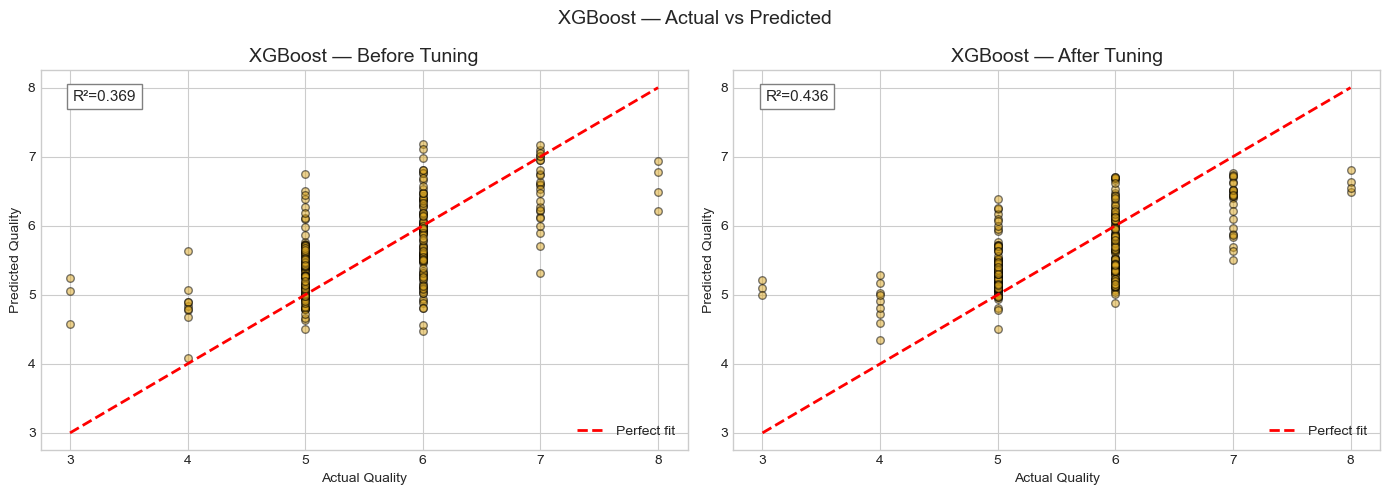

In [26]:
# ── XGB Before vs After — Actual vs Predicted ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pred, title in zip(
        axes,
        [xgb_base_pred, xgb_tuned_pred],
        ["XGBoost — Before Tuning", "XGBoost — After Tuning"]):
    ax.scatter(y_test, pred, alpha=0.5, color="goldenrod", edgecolors="k", s=30)
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], "r--", lw=2, label="Perfect fit")
    ax.set_xlabel("Actual Quality")
    ax.set_ylabel("Predicted Quality")
    ax.set_title(title)
    ax.legend()
    ax.text(0.05, 0.92, f"R²={r2_score(y_test, pred):.3f}",
            transform=ax.transAxes, fontsize=11,
            bbox=dict(facecolor="white", edgecolor="gray"))
plt.suptitle("XGBoost — Actual vs Predicted", fontsize=14)
plt.tight_layout()
plt.show()


## Full Model Comparison

In [27]:
# ── Results DataFrame ────────────────────────────────────────────────────────
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


                            Model    MAE   RMSE     R2  CV_R2
    Random Forest — Before Tuning 0.4910 0.6324 0.4214 0.3734
     Random Forest — After Tuning 0.4985 0.6288 0.4279 0.3920
Gradient Boosting — Before Tuning 0.5048 0.6417 0.4043 0.3611
 Gradient Boosting — After Tuning 0.4979 0.6363 0.4142 0.3864
          XGBoost — Before Tuning 0.5057 0.6606 0.3686 0.2666
           XGBoost — After Tuning 0.4882 0.6246 0.4356 0.3955


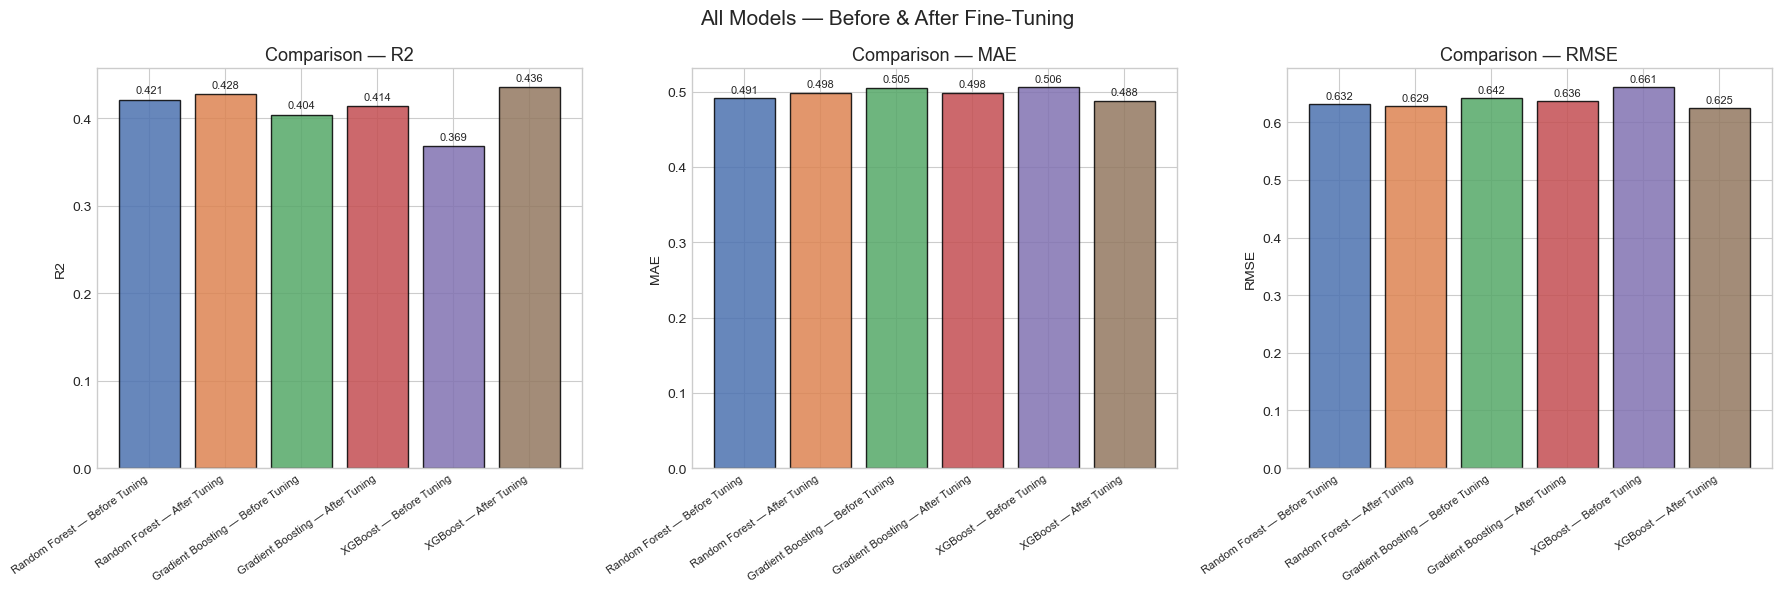

In [28]:
# ── Comparison Chart — R², MAE, RMSE side-by-side ────────────────────────────
metrics = ["R2", "MAE", "RMSE"]
colors  = ["#4c72b0", "#dd8452", "#55a868",
           "#c44e52", "#8172b2", "#937860"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, metric in zip(axes, metrics):
    bars = ax.bar(range(len(results_df)), results_df[metric],
                  color=colors[:len(results_df)], edgecolor="black", alpha=0.85)
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels(results_df["Model"],
                       rotation=35, ha="right", fontsize=8)
    ax.set_title(f"Comparison — {metric}", fontsize=13)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
plt.suptitle("All Models — Before & After Fine-Tuning", fontsize=15)
plt.tight_layout()
plt.show()


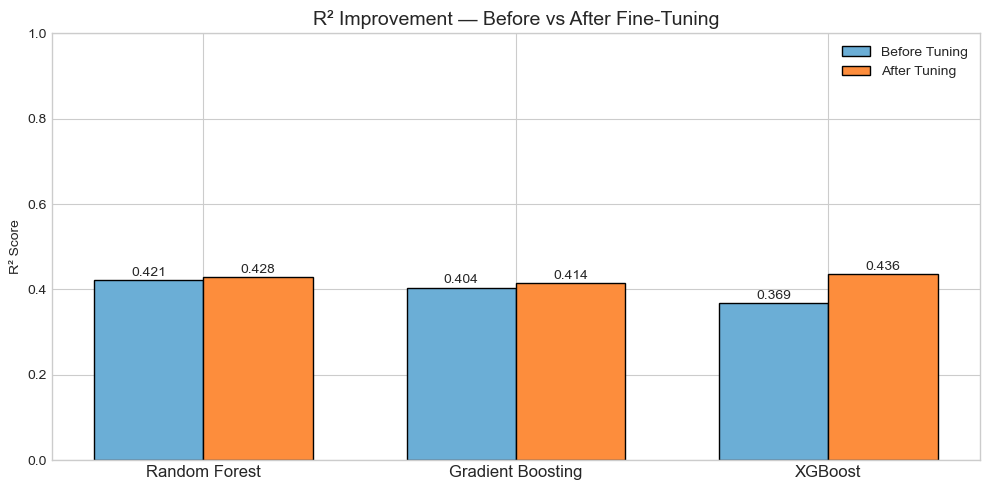

In [29]:
# ── R² Improvement: Before vs After for each model ─────────────────────────
pairs = [
    ("Random Forest",     results_df.loc[0, "R2"], results_df.loc[1, "R2"]),
    ("Gradient Boosting", results_df.loc[2, "R2"], results_df.loc[3, "R2"]),
    ("XGBoost",           results_df.loc[4, "R2"], results_df.loc[5, "R2"]),
]
model_names = [p[0] for p in pairs]
before_r2   = [p[1] for p in pairs]
after_r2    = [p[2] for p in pairs]

x = np.arange(len(model_names))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, before_r2, w, label="Before Tuning",
            color="#6baed6", edgecolor="black")
b2 = ax.bar(x + w/2, after_r2,  w, label="After Tuning",
            color="#fd8d3c", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylabel("R² Score")
ax.set_title("R² Improvement — Before vs After Fine-Tuning", fontsize=14)
ax.legend()
ax.set_ylim(0, 1)
for bar in [*b1, *b2]:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}",
            ha="center", fontsize=10)
plt.tight_layout()
plt.show()


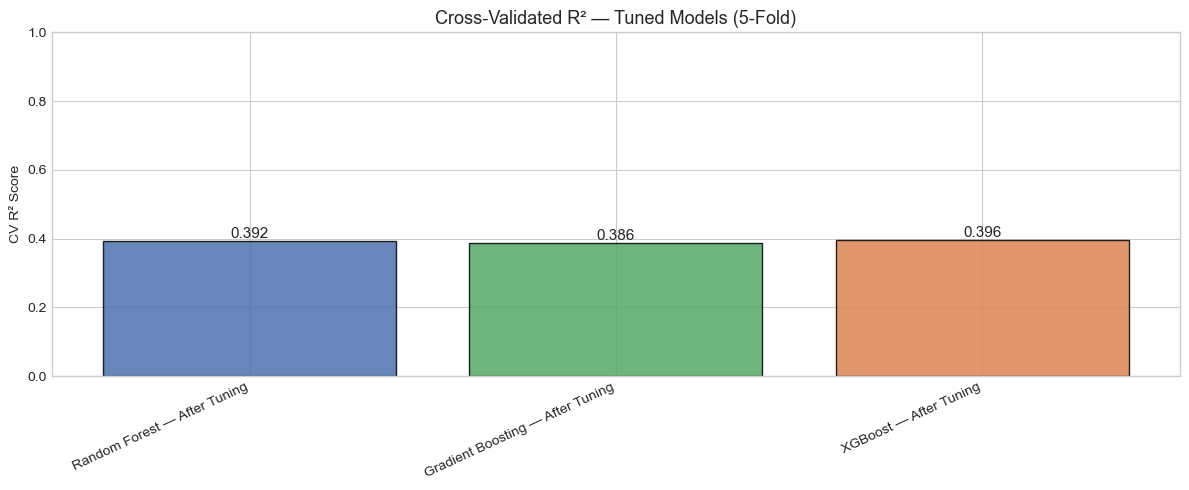

In [30]:
# ── CV R² Comparison (robustness) ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
tuned_only = results_df[results_df["Model"].str.contains("After")]
bars = ax.bar(tuned_only["Model"], tuned_only["CV_R2"],
              color=["#4c72b0", "#55a868", "#dd8452"],
              edgecolor="black", alpha=0.85)
ax.set_title("Cross-Validated R² — Tuned Models (5-Fold)", fontsize=13)
ax.set_ylabel("CV R² Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=25, ha="right")
for bar, val in zip(bars, tuned_only["CV_R2"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()


## Select Best Model & Save

In [31]:
# ── Pick the model with highest R² among TUNED models ────────────────────────
tuned_results = results_df[results_df["Model"].str.contains("After")].copy()
tuned_results = tuned_results.reset_index(drop=True)
best_idx  = tuned_results["R2"].idxmax()
best_row  = tuned_results.loc[best_idx]

print("\n" + "="*50)
print(f"  🏆  BEST MODEL: {best_row['Model']}")
print("="*50)
print(f"  R²   : {best_row['R2']}")
print(f"  MAE  : {best_row['MAE']}")
print(f"  RMSE : {best_row['RMSE']}")
print(f"  CV R²: {best_row['CV_R2']}")



  🏆  BEST MODEL: XGBoost — After Tuning
  R²   : 0.4356
  MAE  : 0.4882
  RMSE : 0.6246
  CV R²: 0.3955


In [32]:
# ── Map name → estimator object ──────────────────────────────────────────────
model_map = {
    "Random Forest — After Tuning":     rf_tuned,
    "Gradient Boosting — After Tuning": gb_tuned,
    "XGBoost — After Tuning":           xgb_tuned,
}
best_model = model_map[best_row["Model"]]

# ── Save best model + scaler ──────────────────────────────────────────────────
joblib.dump(best_model, "best_wine_model.pkl")
joblib.dump(scaler,     "wine_scaler.pkl")
joblib.dump(list(X.columns), "feature_names.pkl")

print("\n✅ Saved:")
print("   best_wine_model.pkl")
print("   wine_scaler.pkl")
print("   feature_names.pkl")



✅ Saved:
   best_wine_model.pkl
   wine_scaler.pkl
   feature_names.pkl


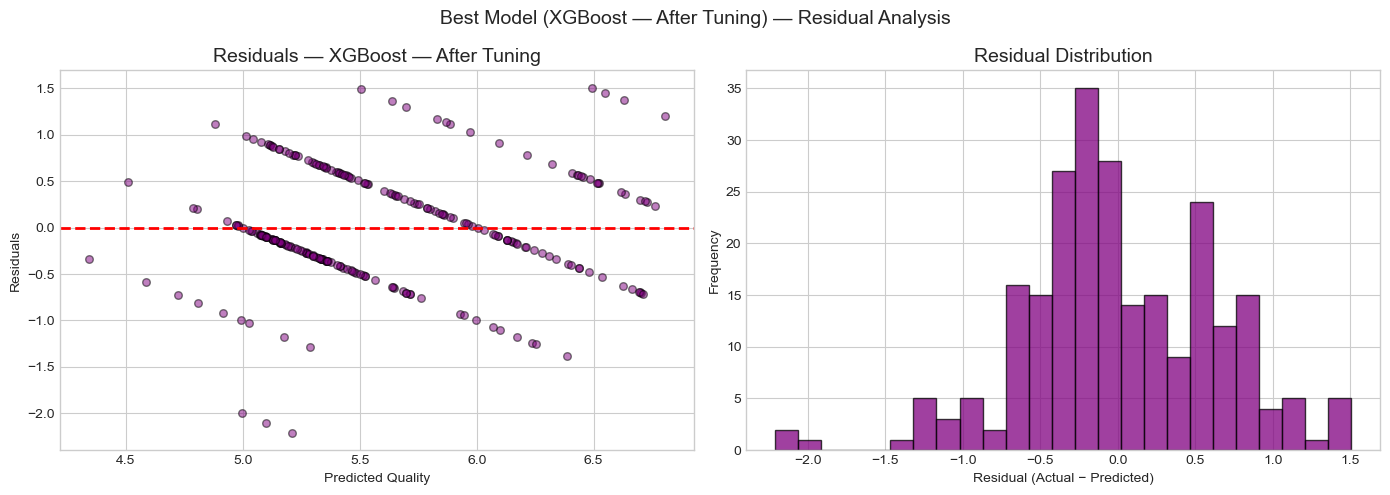

In [33]:
# ── Residuals Plot for best model ─────────────────────────────────────────────
best_pred = best_model.predict(X_test_sc)
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(best_pred, residuals, alpha=0.5, color="purple",
                edgecolors="k", s=30)
axes[0].axhline(0, color="red", linestyle="--", lw=2)
axes[0].set_xlabel("Predicted Quality")
axes[0].set_ylabel("Residuals")
axes[0].set_title(f"Residuals — {best_row['Model']}")

axes[1].hist(residuals, bins=25, color="purple", edgecolor="black",
             alpha=0.75)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual (Actual − Predicted)")
axes[1].set_ylabel("Frequency")

plt.suptitle(f"Best Model ({best_row['Model']}) — Residual Analysis",
             fontsize=14)
plt.tight_layout()
plt.show()
